<a href="https://colab.research.google.com/github/Leahh02/Physical-Computing/blob/main/S2026_HW3_BME548.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Homework 3: Coding Part (PyTorch)
Due: April 3, 2026 at 11:59 pm

Submit through Canvas

**Dataset**: “A dataset for microscopic peripheral blood cell images for development of automatic recognition systems” (Mendeley Data, DOI: 10.17632/snkd93bnjr.1).


In [1]:
# imports
import os, glob, random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import StratifiedKFold

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# reproducibility

def set_seed(seed: int = 0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(548)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


## What you are expected to do in this assignment
In this homework, you will build and analyze a small convolutional neural network for **8-class white blood cell classification**.

Across the notebook, you will:
- build a baseline CNN in **PyTorch**
- modify the architecture to replace pooling with **strided convolutions**
- choose a **loss function, optimizer, and learning rate**
- train the model and monitor **training / validation loss and accuracy**
- count the number of trainable parameters
- visualize learned convolutional filters
- compare training behavior under different learning rates
- test **batch normalization** and **data augmentation**
- implement a **custom Fourier-domain filtering layer** and train a model using it

Unless a section explicitly says otherwise, you may choose reasonable implementation details yourself. The goal is not only to make the code run, but to demonstrate that you understand **what the model is doing** and **how design choices affect performance**.


# 1. Download the white blood cell classification data

The homework uses the folder layout:
`./PBC_dataset_normal_DIB/<class_name>/*.jpg`

If you already have the dataset extracted locally, place it there before running the rest of the notebook.


In [2]:
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/My Drive/')

Mounted at /content/drive


In [3]:
# if this breaks please contact the TAs
#!wget -O data.zip https://data.mendeley.com/public-files/datasets/snkd93bnjr/files/2fc38728-2ae7-4a62-a857-032af82334c3/file_downloaded
#!unzip data.zip

In [4]:
# (Optional) dataset download helper
# If you already have the folder, you can skip this cell.

# Expected structure:
# PBC_dataset_normal_DIB/
#   basophil/
#   eosinophil/
#   erthroblast/
#   ig/
#   lymphocyte/
#   monocyte/
#   neutrophil/
#   platelet/



DATA_ROOT = "PBC_dataset_normal_DIB"
print("Exists?", os.path.isdir(DATA_ROOT), "->", os.path.abspath(DATA_ROOT))

Exists? True -> /content/drive/My Drive/PBC_dataset_normal_DIB


## Load a sample image

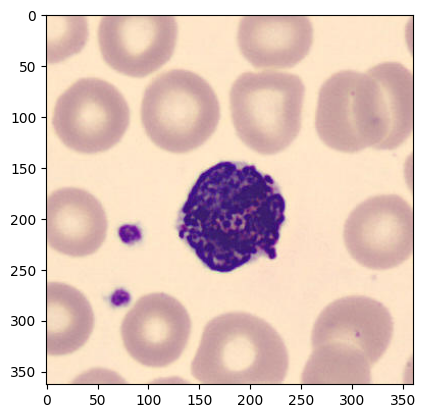

In [5]:
# loading a sample image (update the path if needed)
sample_path = os.path.join(DATA_ROOT, "basophil", "BA_100102.jpg")
if os.path.exists(sample_path):
    img = Image.open(sample_path)
    display(img) if "display" in globals() else plt.imshow(img)
else:
    print("Sample image not found:", sample_path)


# 2. Define a PyTorch model

You will implement a CNN architecture using **PyTorch**.

Please define your model with the following layers:
1. Conv (5x5) + ReLU
2. Conv (5x5) + ReLU
3. MaxPool (2x2)
4. Conv (5x5) + ReLU
5. Conv (5x5) + ReLU
6. MaxPool (2x2)
7. Flatten
8. Linear -> 8 classes

## Important notes
- You are free to choose the **number of channels / feature maps** in the convolution layers.
- You are free to choose the hidden dimensionality right before the final classification output, if your implementation uses one.
- Try not to make the model extremely wide, since that can make training unnecessarily slow.
- The final output must have **8 logits**, one for each class.
- When using `nn.CrossEntropyLoss`, do **not** add a softmax layer to the model output.


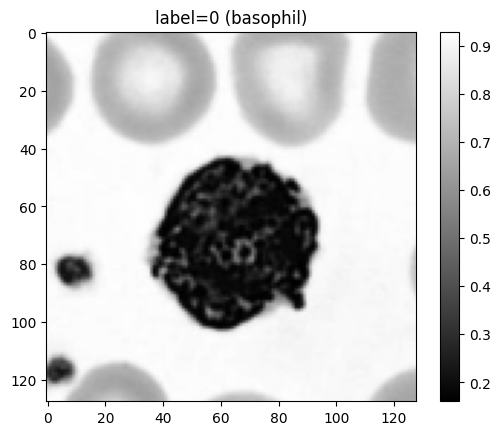

train size: 12432 val size: 3109


In [6]:
# DO NOT EDIT
# dataset utilities and preprocessing

CELL_TYPES = ['basophil', 'eosinophil', 'erthroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']
NUM_CLASSES = len(CELL_TYPES)

def list_image_paths(data_root: str, class_names):
    paths, labels = [], []
    for idx, cname in enumerate(class_names):
        class_dir = os.path.join(data_root, cname)
        for p in sorted(glob.glob(os.path.join(class_dir, "*.jpg"))):
            paths.append(p)
            labels.append(idx)
    return paths, np.array(labels, dtype=np.int64)

# transforms matching the original "resize to 200 then center crop to 128 and grayscale"
CROP_SIZE = 128

base_transform = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.CenterCrop(CROP_SIZE),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),  # -> float32 in [0,1], shape (1,H,W)
])

class WBCCropDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = list(paths)
        self.labels = np.array(labels, dtype=np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        x = self.transform(img) if self.transform else transforms.ToTensor()(img)
        y = int(self.labels[i])
        return x, y

# build train/val split (StratifiedKFold, first split)
all_paths, all_labels = list_image_paths(DATA_ROOT, CELL_TYPES)

if len(all_paths) == 0:
    raise RuntimeError(
        f"No images found. Expected class folders under: {DATA_ROOT}/{{{', '.join(CELL_TYPES)}}}"
    )

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
train_idx, val_idx = next(skf.split(np.zeros_like(all_labels), all_labels))

train_ds = WBCCropDataset(np.array(all_paths)[train_idx], all_labels[train_idx], transform=base_transform)
val_ds   = WBCCropDataset(np.array(all_paths)[val_idx],   all_labels[val_idx],   transform=base_transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

# visualize one example after preprocessing
x0, y0 = train_ds[0]
plt.imshow(x0.squeeze(0), cmap="gray")
plt.title(f"label={y0} ({CELL_TYPES[y0]})")
plt.colorbar()
plt.show()

print("train size:", len(train_ds), "val size:", len(val_ds))

## (a) Define your model with the specified layers - 5 points

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        self.layer = nn.Sequential(
           #  Conv(5x5, stride=1) -> ReLU
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1),
            nn.ReLU(),

            # Conv(5x5, stride=1) -> ReLU
            nn.Conv2d(in_channels=6, out_channels=6, kernel_size=5, stride=1),
            nn.ReLU(),

            #   MaxPool(2x2)
            nn.MaxPool2d(kernel_size=2),

            #  Conv(5x5, stride=1) -> ReLU
            nn.Conv2d(in_channels=6, out_channels=6, kernel_size=5, stride=1),
            nn.ReLU(),

            #  Conv(5x5, stride=1) -> ReLU
            nn.Conv2d(in_channels=6, out_channels=6, kernel_size=5, stride=1),
            nn.ReLU(),

            #   MaxPool(2x2)
            nn.MaxPool2d(kernel_size=2),

            #   Flatten
            nn.Flatten(),

            #   Linear -> 8 classes
            nn.Linear(in_features=6 * 26 * 26, out_features=num_classes)
        )


    def forward(self, x):
        x = self.layer(x)
        return x

cnn_model = SimpleCNN(num_classes=NUM_CLASSES).to(device)
print(cnn_model)

SimpleCNN(
  (layer): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(6, 6, kernel_size=(5, 5), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(6, 6, kernel_size=(5, 5), stride=(1, 1))
    (6): ReLU()
    (7): Conv2d(6, 6, kernel_size=(5, 5), stride=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Flatten(start_dim=1, end_dim=-1)
    (11): Linear(in_features=4056, out_features=8, bias=True)
  )
)


In [8]:
x = torch.randn(1, 1, 128, 128)
model = SimpleCNN()
for layer in model.layer:
    x = layer(x)
    print(x.shape)

torch.Size([1, 6, 124, 124])
torch.Size([1, 6, 124, 124])
torch.Size([1, 6, 120, 120])
torch.Size([1, 6, 120, 120])
torch.Size([1, 6, 60, 60])
torch.Size([1, 6, 56, 56])
torch.Size([1, 6, 56, 56])
torch.Size([1, 6, 52, 52])
torch.Size([1, 6, 52, 52])
torch.Size([1, 6, 26, 26])
torch.Size([1, 4056])
torch.Size([1, 8])


## (b) Remove max-pooling and match the downsampling using strided convolutions - 5 points

Create a second version of the model in which you **remove the pooling layers**.

Instead of max-pooling, modify the stride of the appropriate convolution layers so that the tensor is reduced in size by about the **same total amount** as before.

In [9]:
class StridedCNN(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        self.layer = nn.Sequential(
           #  Conv(5x5, stride=1) -> ReLU
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1),
            nn.ReLU(),

            # Conv(5x5, stride=1) -> ReLU
            nn.Conv2d(in_channels=6, out_channels=6, kernel_size=5, stride=1),
            nn.ReLU(),

            #   Replace MaxPool(2x2)
            nn.Conv2d(in_channels=6, out_channels=6, kernel_size=2, stride=2),

            #  Conv(5x5, stride=1) -> ReLU
            nn.Conv2d(in_channels=6, out_channels=6, kernel_size=5, stride=1),
            nn.ReLU(),

            #  Conv(5x5, stride=1) -> ReLU
            nn.Conv2d(in_channels=6, out_channels=6, kernel_size=5, stride=1),
            nn.ReLU(),

            #   Replace MaxPool(2x2)
            nn.Conv2d(in_channels=6, out_channels=6, kernel_size=2, stride=2),

            #   Flatten
            nn.Flatten(),

            #   Linear -> 8 classes
            nn.Linear(in_features=6 * 26 * 26, out_features=num_classes)
        )

    def forward(self, x):
        x = self.layer(x)
        return x

strided_model = StridedCNN(num_classes=NUM_CLASSES).to(device)

# sanity-check sizes
with torch.no_grad():
    dummy = torch.zeros(1, 1, 128, 128, device=device)
    out1 = cnn_model(dummy)
    out2 = strided_model(dummy)
print("SimpleCNN logits shape:", tuple(out1.shape))
print("StridedCNN logits shape:", tuple(out2.shape))

SimpleCNN logits shape: (1, 8)
StridedCNN logits shape: (1, 8)


## (c) Define an optimizer, learning rate, loss function, and training loop utilities - 5 points

Set up the pieces needed for supervised training.

Your code in this section should:
- choose a loss function appropriate for **multi-class classification**
- choose an optimizer
- set a learning rate
- implement helper functions for one training epoch and one validation / evaluation pass
- track both **loss** and **accuracy**

The rest of the notebook should be able to call these utilities repeatedly during training.

In [10]:
# TODO: write helper functions for training and evaluation.
# Suggested pieces:
#   1. accuracy_from_logits(logits, y)
#   2. train_one_epoch(model, loader, optimizer, criterion)
#   3. eval_one_epoch(model, loader, criterion)
#   4. fit(model, train_loader, val_loader, epochs=10, lr=1e-3)
#
# Your fit(...) function should return a dictionary with keys:
#   "loss", "val_loss", "acc", "val_acc"
#
# After writing fit(...), initialize cnn_model as an instance of SimpleCNN.

# TODO
import torch.optim as optim

def accuracy_from_logits(logits, y, total, correct):
    _, preds = torch.max(logits, 1)
    total += y.size(0)
    correct += (preds == y).sum().item()
    return total, correct


def train_one_epoch(model, loader, optimizer, criterion):
    running_loss = 0.0
    total = 0
    correct = 0
    model.train()
    for batch_idx, (inputs, labels) in enumerate(loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

        total, correct = accuracy_from_logits(outputs, labels, total, correct)
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = correct / total
    return model, epoch_loss, epoch_acc


def eval_one_epoch(model, loader, criterion):
    model.eval()
    val_correct = 0
    val_total = 0
    running_loss = 0.0
    with torch.no_grad():
        for val_inputs, val_labels in loader:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
            val_outputs = model(val_inputs)
            _, val_predicted = torch.max(val_outputs, 1)
            val_total += val_labels.size(0)
            val_correct += (val_predicted == val_labels).sum().item()
            loss = criterion(val_outputs, val_labels)
            running_loss += loss.item() * val_inputs.size(0)
    val_acc = val_correct / val_total
    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss, val_acc


def fit(model, train_loader, val_loader, epochs=10, lr=1e-3):
    train_acc_history = []  # Store training accuracy for each epoch
    val_acc_history = []  # Store validation accuracy for each epoch
    train_loss_history = []  # Store training accuracy for each epoch
    val_loss_history = []  # Store validation accuracy for each epoch


    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        print(f"Doing epoch: {epoch}")
        model, epoch_train_loss, epoch_train_acc = train_one_epoch(model, train_loader, optimizer, loss_fn)
        print(f"epoch_train_loss, epoch_train_acc: {epoch_train_loss}, {epoch_train_acc}")
        train_acc_history.append(epoch_train_acc)
        train_loss_history.append(epoch_train_loss)

        epoch_val_loss, epoch_val_acc = eval_one_epoch(model, val_loader, loss_fn)
        print(f"epoch_val_loss, epoch_val_acc: {epoch_val_loss}, {epoch_val_acc}")
        val_loss_history.append(epoch_val_loss)
        val_acc_history.append(epoch_val_acc)

    return {
        "loss": train_loss_history,
        "val_loss": val_loss_history,
        "acc": train_acc_history,
        "val_acc": val_acc_history,
    }

## (d) Run optimization for 10–15 epochs and monitor training and validation loss/accuracy - 5 points

During training, record:
- training loss
- validation loss
- training accuracy
- validation accuracy

A reasonable model should typically reach around **75%+ validation accuracy**, although exact performance will vary depending on your implementation details and random initialization. If you do not reach that number, that is still okay as long as your pipeline is correct and you can discuss the behavior you observe.

In [ ]:
epochs = 10
hist = fit(cnn_model, train_loader, val_loader, epochs=epochs, lr=1e-3)

Doing epoch: 0


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


## (e) Plot the training and validation losses and accuracies - 5 points

After training, make **two plots**:
1. training loss and validation loss on the same axes
2. training accuracy and validation accuracy on the same axes

For both plots:
- the horizontal axis should be **epoch**
- both curves should be labeled clearly
- the plots should be readable enough for someone grading the homework to understand the training behavior immediately

In [ ]:
plt.title("Loss Curve")
plt.plot(np.arange(epochs), hist["loss"], label="Training Loss")
plt.plot(np.arange(epochs), hist["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(loc='best')
plt.show()

In [ ]:
plt.title("Learning Curve")
plt.plot(np.arange(epochs), hist["acc"], label="Training Acc")
plt.plot(np.arange(epochs), hist["val_acc"], label="Validation Acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(loc='best')
plt.show()


# 3. How many weight parameters does your network have? - 5 points

First calculate this number by hand and show your work in markdown.
Then verify it in code below.


Note to self: [this article was helpful](https://medium.com/@iamvarman/how-to-calculate-the-number-of-parameters-in-the-cnn-5bd55364d7ca)

To compute number the number of trainable parameters the network has, you need to calculate the number of parameters at each layer and then sum them up.

The number of parameters in a convolutional layer is $(n * m * l +1) * k$ where $n*m$ is the filter size, l is ithe number of input channels, and k is the number of output channels.

There are no parameters in the pooling layer.

In the output layer it's $(n+1)m$ where “n” is the number of inputs and “m” is the number of outputs

So, going through all of my layers:

$(5*5*1+1)*6 = 156$

$(5*5*1+6)*6 = 906$

$(5*5*1+6)*6 = 906$

$(5*5*1+6)*6 = 906$

$(6*26*26+1)*8 = 32456$

$156+906+906+906+32456=35330$

**So the number of trainable parameters should be 35330**

In [ ]:
trainable_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable_params}')


The code matches what I calculated by hand.

# 4. Visualize filters

## (a) Plot all convolution kernels in the first convolutional layer - 5 points

Retrieve the weights from the **first convolutional layer**.

Then:
- convert them to a CPU numpy array if needed
- normalize or rescale them for visualization if helpful
- plot **all** first-layer kernels in a grid

In [ ]:
first_kernels = cnn_model.layer[0].weight.detach().cpu().numpy()
print("First layer weight shape:", first_kernels.shape)
# shape = (out_channels, in_channels, kernel_height, kernel_width)

num_kernels = first_kernels.shape[0]

fig, axes = plt.subplots(1, num_kernels, figsize=(2 * num_kernels, 2))

for i in range(num_kernels):
    kernel = first_kernels[i, 0]
    axes[i].imshow(kernel, cmap="gray")
    axes[i].set_title(f"Filter {i}, Ch {0}", fontsize=8)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## (b) Plot some of the convolution kernels in the second convolutional layer - 5 points

Repeat the process for the **second convolutional layer**.

Because later convolutional layers can contain many more kernels / channels, it is fine to plot only a **representative subset** here rather than everything.

You should still make the visualization clean and interpretable.

In [ ]:
second_kernels = cnn_model.layer[2].weight.detach().cpu().numpy()

print("Second layer weight shape:", second_kernels.shape)

print(second_kernels.shape[0])

num_outs = second_kernels.shape[0]

num_ins = second_kernels.shape[1]

fig, axes = plt.subplots(num_outs, num_ins, figsize=(2 * num_ins, 2 * num_outs))

for i in range(num_outs):
    for j in range(num_ins):
        kernel = second_kernels[i, j]   # just show input channel 0 for simplicity
        axes[i, j].imshow(kernel, cmap="gray")
        axes[i, j].set_title(f"Filter {i}, Ch {j}", fontsize=8)
        axes[i, j].axis("off")


plt.tight_layout()
plt.show()


# 5. Try playing with the learning rate

Re-train the same model with multiple learning rates and compare the training behavior.

The point of this section is to see how the learning rate affects:
- convergence speed
- stability of training
- final validation performance


## (a) Increase and decrease the learning rate and plot the resulting loss and accuracy curves - 10 points

Choose multiple learning rates (for example, one smaller than your baseline, one near your baseline, and one larger).

For each learning rate:
- reinitialize and retrain the model
- record training / validation loss and accuracy
- compare the resulting curves

You can either:
- make separate plots for each learning rate, or
- overlay multiple runs in a way that remains easy to read

In [ ]:
learning_rates = [0.1, 3e-3, 3e-4, 1e-5, 1e-7]
learning_hist = {}

for key in learning_rates:
    model = SimpleCNN(num_classes=NUM_CLASSES).to(device)
    learning_hist[key] = fit(model, train_loader, val_loader, epochs=epochs, lr=key)

In [ ]:
plt.title("Validation Loss")

for key, value in learning_hist.items():
    my_label = "lr = " + str(key)
    plt.plot(np.arange(epochs), value["val_loss"], label=my_label)
plt.plot(np.arange(epochs), hist["val_loss"], label="lr = 1e-3 (default)"

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(loc='best')
plt.show()

## (b) Comment on any trends you observe as a function of learning rate - 5 points

In [ ]:
plt.title("Validation Accuracy")

for key, value in learning_hist.items():
    my_label = "lr = " + str(key)
    plt.plot(np.arange(epochs), value["val_acc"], label=my_label)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(loc='best')
plt.show()

Write your answer here.

# 6. Adding Batch Norm - 5 points

Fix a learning rate and modify the model by adding **batch normalization** after the **second** and **fourth** convolution layers.

Then:
- train the new model
- plot training / validation loss and accuracy curves
- compare its behavior to the model without batch normalization

In a short written comment, explain whether batch normalization appears to improve training speed, stability, or final performance in your experiment.

In [ ]:
class CNNWithBN(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        self.layer = nn.Sequential(
           #  Conv(5x5, stride=1) -> ReLU
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1),
            nn.ReLU(),

            # Conv(5x5, stride=1) -> ReLU
            nn.Conv2d(in_channels=6, out_channels=6, kernel_size=5, stride=1),
            nn.BatchNorm2d(num_features=6),
            nn.ReLU(),

            #   MaxPool(2x2)
            nn.MaxPool2d(kernel_size=2),

            #  Conv(5x5, stride=1) -> ReLU
            nn.Conv2d(in_channels=6, out_channels=6, kernel_size=5, stride=1),
            nn.ReLU(),

            #  Conv(5x5, stride=1) -> ReLU
            nn.Conv2d(in_channels=6, out_channels=6, kernel_size=5, stride=1),
            nn.BatchNorm2d(num_features=6),
            nn.ReLU(),

            #   MaxPool(2x2)
            nn.MaxPool2d(kernel_size=2),

            #   Flatten
            nn.Flatten(),

            #   Linear -> 8 classes
            nn.Linear(in_features=6 * 26 * 26, out_features=8)
        )


    def forward(self, x):
        x = self.layer(x)
        return x

bn_model = CNNWithBN(num_classes=NUM_CLASSES).to(device)
hist_bn = fit(bn_model, train_loader, val_loader, epochs=10, lr=1e-3)

In [ ]:
plt.title("Loss Curve")
plt.plot(np.arange(epochs), hist_bn["loss"], label="Training Loss")
plt.plot(np.arange(epochs), hist_bn["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(loc='best')
plt.show()

In [ ]:
plt.title("Learning Curve")
plt.plot(np.arange(epochs), hist["acc"], label="Training Acc")
plt.plot(np.arange(epochs), hist["val_acc"], label="Validation Acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(loc='best')
plt.show()

# 7. Data Augmentation - 5 points

Now, instead of feeding the original training images directly to the network, augment them first.

Use augmentations equivalent to:
- horizontal flips
- vertical flips
- random rotations up to about **20 degrees**

In PyTorch, this can be done with `torchvision.transforms`.

Then:
- retrain the model with augmented training data
- plot training / validation loss and accuracy curves
- briefly comment on what effect augmentation had on your model

You should keep the validation set unaugmented except for any standard deterministic preprocessing.

In [ ]:
all_transform = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.CenterCrop(CROP_SIZE),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),  # -> float32 in [0,1], shape (1,H,W)
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=(0, 20))
])

transformed_train_ds = WBCCropDataset(np.array(all_paths)[train_idx], all_labels[train_idx], transform=all_transform)
transformed_val_ds   = WBCCropDataset(np.array(all_paths)[val_idx],   all_labels[val_idx],   transform=all_transform)

transformed_train_loader = DataLoader(transformed_train_ds, batch_size=32, shuffle=True,  num_workers=0, pin_memory=True)
transformed_val_loader   = DataLoader(transformed_val_ds,   batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

# visualize one example after preprocessing
x0, y0 = transformed_train_ds[0]
plt.imshow(x0.squeeze(0), cmap="gray")
plt.title(f"label={y0} ({CELL_TYPES[y0]})")
plt.colorbar()
plt.show()

print("train size:", len(transformed_train_ds), "val size:", len(transformed_val_ds))

In [ ]:
epochs = 10
transformed_cnn_model = SimpleCNN(num_classes=NUM_CLASSES).to(device)
transformed_hist = fit(transformed_cnn_model, transformed_train_loader, transformed_val_loader, epochs=epochs, lr=1e-3)

In [ ]:
plt.title("Loss Curve")
plt.plot(np.arange(epochs), transformed_hist["loss"], label="Training Loss")
plt.plot(np.arange(epochs), transformed_hist["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(loc='best')
plt.show()

In [ ]:
plt.title("Learning Curve")
plt.plot(np.arange(epochs), transformed_hist["acc"], label="Training Acc")
plt.plot(np.arange(epochs), transformed_hist["val_acc"], label="Validation Acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(loc='best')
plt.show()


# 8. Custom layer for Fourier filtering

Implement a custom PyTorch module that applies:
1. a 2D FFT,
2. multiplication by a learnable Fourier mask,
3. an inverse FFT.

Then use that layer as the first layer of a classification model.

## What this section is about
This part asks you to build a layer that operates in the **Fourier domain** instead of directly in the spatial domain.

Conceptually, your layer should:
- take an image (or each channel of an image),
- transform it into frequency space,
- apply a trainable frequency-domain filter,
- transform it back to image space,
- produce a real-valued output that can be passed into the rest of a CNN.

You should use **PyTorch FFT operations**, not NumPy FFTs inside the model forward pass, so that gradients can propagate correctly.


## (a) Create circular mask - 5 points

Create an initial **circular Fourier mask**.

This mask will be used to initialize the learnable Fourier filter.

You should decide:
- the mask size
- the radius of the pass region
- whether values outside the circle are 0 and inside are 1 (or vice versa, if you clearly define your convention)

Plot the mask so it is easy to verify visually before using it in the model.

In [ ]:
# TODO: create and plot a circular mask before training.

def create_circular_mask(x_dim, y_dim, radius):
  mask = torch.zeros((x_dim, y_dim), dtype=torch.float32)
  xcenter = x_dim // 2
  ycenter = y_dim //2

  for i in range(x_dim):
    for j in range(y_dim):
          val = ((i - xcenter)**2) + ((j-ycenter)**2)
          if val < (radius **2):
              mask[i, j] = 1

  return mask


In [ ]:
my_mask = create_circular_mask(128, 128, 32)

plt.rcParams['image.cmap'] = 'gray'
fig, ax = plt.subplots()
ax.imshow(my_mask)

## (b) Create FourierFilter class - 25 points

Implement a custom `nn.Module` called something like `FourierFilter`.

Its forward pass should:
1. accept an image tensor
2. cast / handle the tensor appropriately for FFT operations
3. compute a 2D Fourier transform
4. multiply by a **learnable mask parameter**
5. compute the inverse transform
6. convert the result back into a real-valued image representation suitable for later layers

Be careful about:
- tensor shapes
- channel handling
- complex-valued intermediate quantities
- making sure the Fourier mask is a trainable parameter

This is the main custom-layer coding portion of the homework.

In [ ]:
# TODO: implement the helper functions below and complete the FourierFilter module.

# Hints:
# - create_circular_mask(...) should return a float tensor with ones inside the radius and zeros outside.
# - Use torch.fft.fft2 and torch.fft.ifft2.
# - Apply fftshift before multiplying by the learnable mask, then undo the shift before the inverse FFT.
# - Return a real-valued tensor with the same dtype as the input.

# TODO

class CustumFourierFilter(nn.Module):
    def __init__(self, x_dim=128, y_dim=128, mask_radius=32):
      super().__init__()
      self.x_dim = x_dim
      self.y_dim = y_dim
      self.mask_radius = mask_radius
      init_mask = create_circular_mask(x_dim, y_dim, mask_radius)
      self.mask = nn.Parameter(init_mask, requires_grad=True)

    def forward(self, input):
      x = input.to(torch.float32)
      x_fft = torch.fft.fft2(x)
      x_fft = torch.fft.fftshift(x_fft, dim=(-2, -1))
      x_fft = x_fft * self.mask[None, None, :, :]
      x_fft = torch.fft.ifftshift(x_fft, dim=(-2, -1))
      x_ifft = torch.fft.ifft2(x_fft)
      out = x_ifft.real.to(input.dtype)
      return out

## (c) Create and train a model that uses FourierFilter as the first layer - 5 points

Build a classifier whose first layer is your custom Fourier filtering module.

Then train it on the same white blood cell classification task.

You do not need to design a huge architecture here — the main goal is to show that your custom layer can be integrated into an end-to-end trainable PyTorch model.

In [ ]:
class FourierCNN(nn.Module):
    def __init__(self, num_classes=8, h=128, w=128):
        super().__init__()

        self.features = nn.Sequential(
            CustumFourierFilter(x_dim=h, y_dim=w, mask_radius=32),
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1),
            nn.ReLU(),

            # Conv(5x5, stride=1) -> ReLU
            nn.Conv2d(in_channels=6, out_channels=6, kernel_size=5, stride=1),
            nn.ReLU(),

            #   MaxPool(2x2)
            nn.MaxPool2d(kernel_size=2),

            #   Flatten
            nn.Flatten(),
        )
        self.classifier = nn.Linear(6 * 60 * 60, num_classes)

    def _features(self, x):
        return self.features(x)

    def forward(self, x):
        x = self._features(x)
        x = self.classifier(x)

fourier_model = FourierCNN(num_classes=NUM_CLASSES, h=128, w=128).to(device)
init_weights = fourier_model.classifier.weight.detach().cpu().numpy().copy()
print(fourier_model)

In [ ]:
epochs = 15
fourier_hist = fit(fourier_model, train_loader, val_loader, epochs=epochs, lr=1e-3)

## (d) Compare the Fourier masks before and after training by plotting them - 5 points

Plot the Fourier mask:
- at initialization / before training
- after training

Then briefly comment on how the learned mask changed.

The purpose is to see whether training pushed the filter toward emphasizing or suppressing particular frequency regions.

In [ ]:
trained_weights = fourier_model.classifier.weight.detach().cpu().numpy().copy()

In [ ]:
# TODO: plot the learned Fourier mask after training

plt.figure()
plt.hist(init_weights.flatten(), bins=50, alpha=0.5, label="Before")
plt.hist(trained_weights.flatten(), bins=50, alpha=0.5, label="After")
plt.title("Weight Distribution Before vs After Training")
plt.xlabel("Weight value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [ ]:
# TODO: plot the Fourier-model training and validation curves
plt.title("Loss Curve")
plt.plot(np.arange(epochs), fourier_hist["loss"], label="Training Loss")
plt.plot(np.arange(epochs), fourier_hist["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(loc='best')
plt.show()

In [ ]:
plt.title("Learning Curve")
plt.plot(np.arange(epochs), fourier_hist["acc"], label="Training Acc")
plt.plot(np.arange(epochs), fourier_hist["val_acc"], label="Validation Acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(loc='best')
plt.show()

Congratulations on finishing this homework! No written portions for this homework and all of the remaining ones!